In [1]:
import pprint
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import csv
import json
import os

In [2]:
DATA_PATH = '/archive/Downloads/datafiles/2024-10-08.json'
CLUSTER = "17"

In [3]:
with open(DATA_PATH) as f:
    data = json.load(f)

In [4]:
data[0]

{'filehash': 'd969e3cdd788e129',
 'category': 'MALICIOUS',
 'cluster': '0',
 'closest_cluster': '339',
 'date': '2024-09-25',
 'uniqueness': '1.0',
 'binded': 'd969e3cdd788e129',
 'instruction_blocks': [{'domain': 'https://ajax.googleapis.com/ajax/libs/jquery/3.6.4/jquery.min.js',
   'instructions': 'GET-Window.document GET-Window.document GET-HTMLDocument.childNodes GET-HTMLDocument.childNodes GET-HTMLDocument.childNodes GET-NodeList.length GET-HTMLHtmlElement.nodeType GET-HTMLDocument.nodeType GET-HTMLDocument.documentElement GET-HTMLDocument.documentElement GET-HTMLDocument.namespaceURI GET-HTMLDocument.ownerDocument GET-HTMLDocument.documentElement GET-HTMLHtmlElement.nodeName CALL-HTMLDocument.createElement CALL-HTMLHtmlElement.appendChild GET-HTMLFieldSetElement.appendChild CALL-HTMLDocument.createElement CALL-HTMLFieldSetElement.appendChild GET-HTMLFieldSetElement.querySelectorAll CALL-HTMLFieldSetElement.querySelectorAll GET-NodeList.length GET-HTMLFieldSetElement.parentNode GE

In [5]:
files = []

for sample in data:
    if sample["cluster"] == CLUSTER:
        files.append(sample)

In [9]:
dates = [file["date"] for file in files]

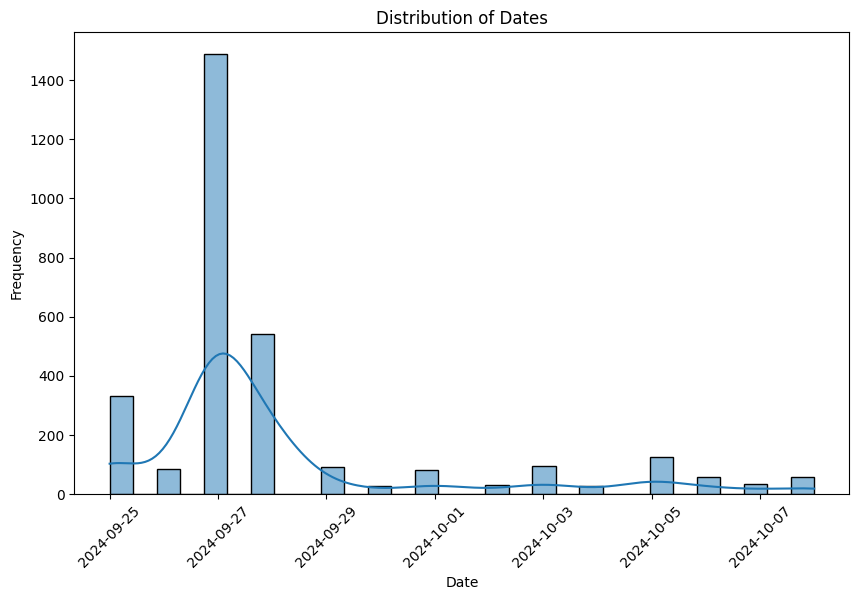

In [12]:
# Convert dates to datetime objects
dates_dt = pd.to_datetime(dates)

# Plot the histogram
plt.figure(figsize=(10, 6))
sns.histplot(dates_dt, bins=30, kde=True)
plt.title('Distribution of Dates')
plt.xlabel('Date')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

In [5]:
clusters = {}
for sample in data:
    cluster = sample["cluster"]
    
    if cluster not in clusters:
        clusters[cluster] = 0

    clusters[cluster] += 1

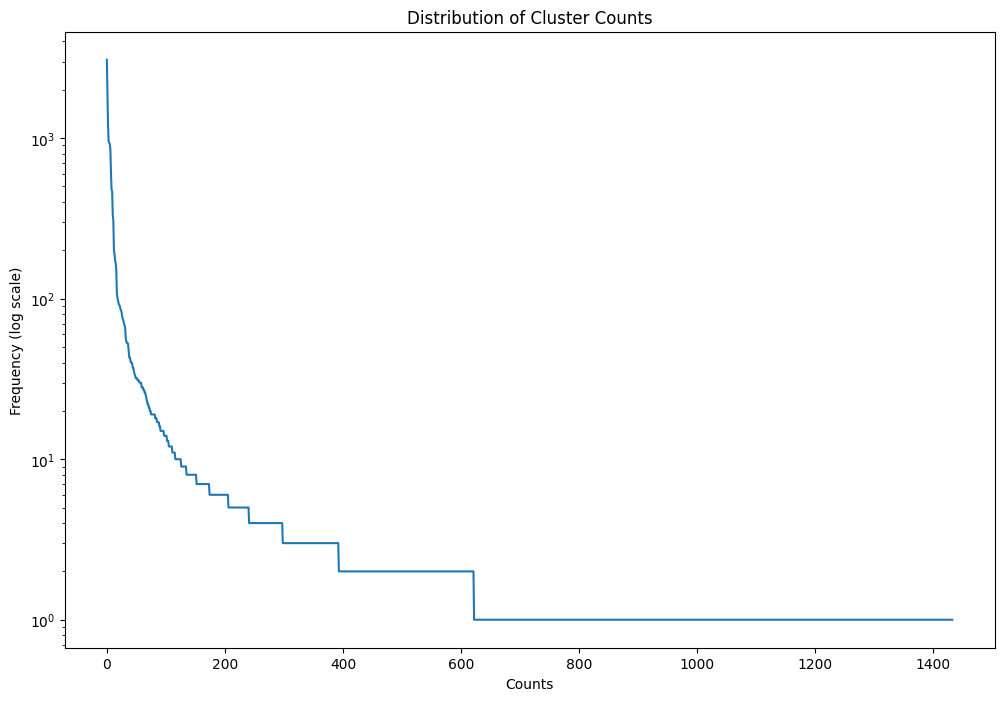

In [26]:
counts = sorted(clusters.values(), reverse=True)

# Convert counts to a pandas Series for easier plotting with seaborn
counts_series = pd.Series(counts)

# Create a seaborn line plot
plt.figure(figsize=(12, 8))
sns.lineplot(data=counts_series)
plt.yscale('log')
plt.title('Distribution of Cluster Counts')
plt.xlabel('Counts')
plt.ylabel('Frequency (log scale)')
plt.show()